In [4]:
import pandas as pd
import pyarrow
import sklearn
import matplotlib
import seaborn
import numpy as np

In [5]:
# reading the data
green_tripdata_raw = pd.read_parquet("homeworks\hw1\green_tripdata_2021-01.parquet")

<>:2: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:2: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\hendr\AppData\Local\Temp\ipykernel_25236\1284306591.py:2: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  green_tripdata_raw = pd.read_parquet("homeworks\hw1\green_tripdata_2021-01.parquet")


# EDA

In [9]:
print("Shape of dataset: ", green_tripdata_raw.shape)

Shape of dataset:  (76518, 20)


In [6]:
green_tripdata_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 76518 entries, 0 to 76517
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               76518 non-null  int64         
 1   lpep_pickup_datetime   76518 non-null  datetime64[us]
 2   lpep_dropoff_datetime  76518 non-null  datetime64[us]
 3   store_and_fwd_flag     40471 non-null  str           
 4   RatecodeID             40471 non-null  float64       
 5   PULocationID           76518 non-null  int64         
 6   DOLocationID           76518 non-null  int64         
 7   passenger_count        40471 non-null  float64       
 8   trip_distance          76518 non-null  float64       
 9   fare_amount            76518 non-null  float64       
 10  extra                  76518 non-null  float64       
 11  mta_tax                76518 non-null  float64       
 12  tip_amount             76518 non-null  float64       
 13  tolls_amount

In [10]:
green_tripdata_raw.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,76518.0,1.90529,1.0,2.0,2.0,2.0,2.0,0.292816
lpep_pickup_datetime,76518,2021-01-16 15:52:22.173018,2009-01-01 00:03:25,2021-01-08 23:22:00,2021-01-16 10:11:45,2021-01-24 09:41:04.250000,2021-01-31 23:46:45,NaN
lpep_dropoff_datetime,76518,2021-01-16 16:12:17.846781,2009-01-01 00:12:25,2021-01-08 23:42:32,2021-01-16 10:30:42.500000,2021-01-24 09:55:45,2021-02-01 16:56:37,NaN
RatecodeID,40471.0,1.143041,1.0,1.0,1.0,1.0,99.0,0.878693
PULocationID,76518.0,109.590371,1.0,55.0,76.0,166.0,265.0,71.063053
DOLocationID,76518.0,130.685577,1.0,65.0,129.0,197.0,265.0,77.101641
passenger_count,40471.0,1.192311,0.0,1.0,1.0,1.0,8.0,0.756395
trip_distance,76518.0,40.862552,0.0,1.3,2.59,5.76,244152.01,1924.408778
fare_amount,76518.0,19.939777,-280.0,9.0,16.73,25.5,284.0,14.984241
extra,76518.0,0.740462,-5.5,0.0,0.0,1.0,8.25,1.184429


In [11]:
# Check missing values
green_tripdata_raw.isnull().sum()

VendorID                     0
lpep_pickup_datetime         0
lpep_dropoff_datetime        0
store_and_fwd_flag       36047
RatecodeID               36047
PULocationID                 0
DOLocationID                 0
passenger_count          36047
trip_distance                0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
ehail_fee                76518
improvement_surcharge        0
total_amount                 0
payment_type             36047
trip_type                36047
congestion_surcharge     36047
dtype: int64

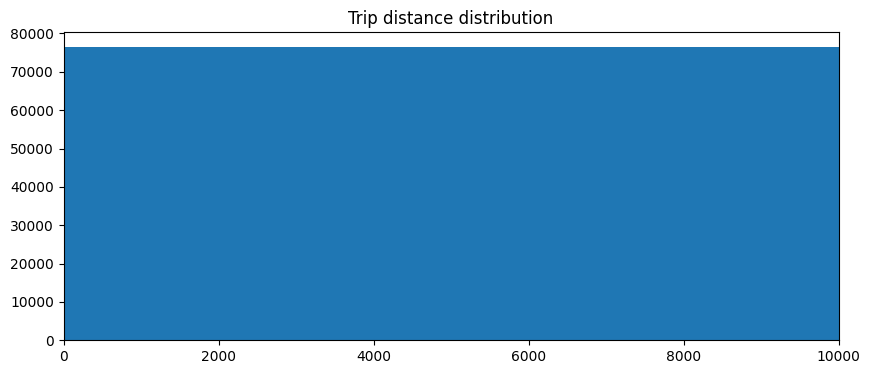

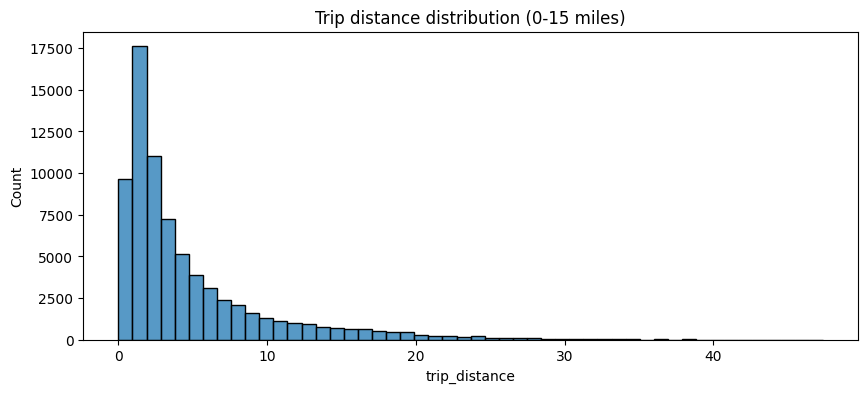

In [28]:
# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of trip distance
plt.figure(figsize=(10, 4))
plt.hist(green_tripdata_raw['trip_distance'], bins=20)
plt.title('Trip distance distribution')
plt.xlim(0, 10000)
plt.show()

# Filtered to reasonable trips and use more bins
filtered = green_tripdata_raw[(green_tripdata_raw['trip_distance'] > 0) & 
                               (green_tripdata_raw['trip_distance'] < 50)]

plt.figure(figsize=(10, 4))
sns.histplot(filtered['trip_distance'], bins=50)
plt.title('Trip distance distribution (0-15 miles)')
plt.show()

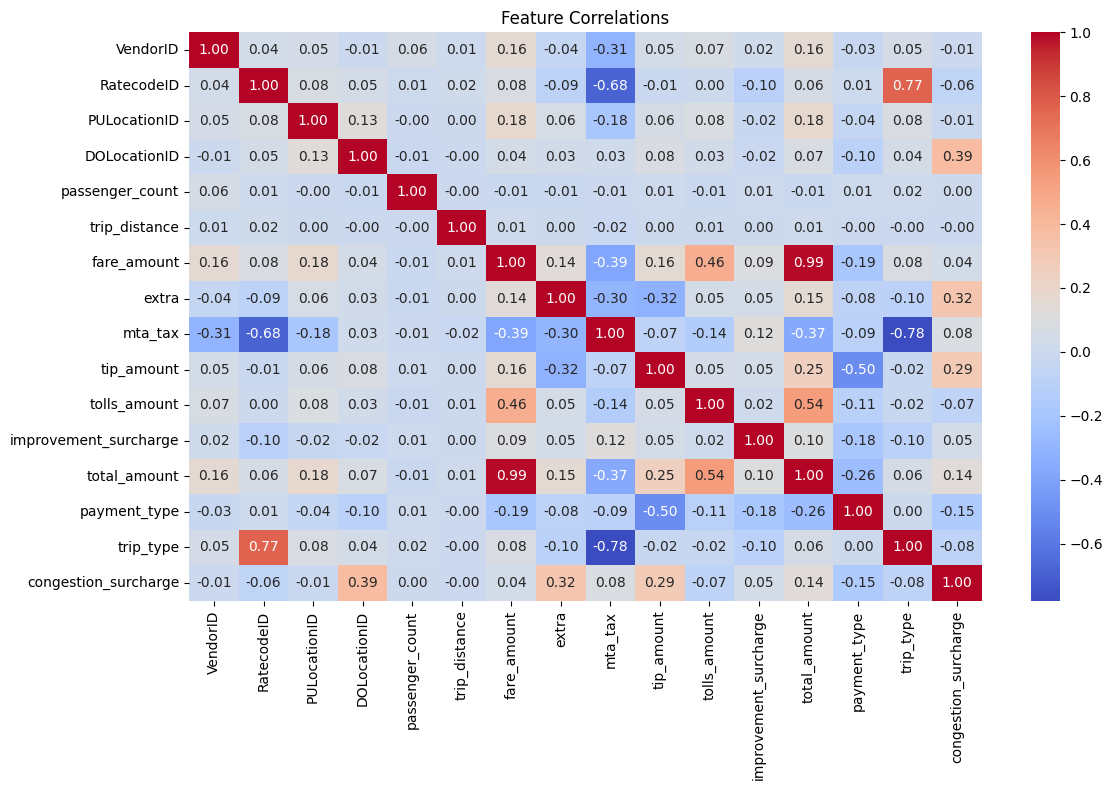

In [29]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(green_tripdata_raw.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlations')
plt.tight_layout()
plt.show()

# Modelling


In [38]:
# Feature selection
features_reg = ['trip_distance', 'DOLocationID', 'PULocationID']

# drop nulls and filter outliers
df = green_tripdata_raw[features_reg + ['total_amount', 'payment_type']].dropna()
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]
df = df[(df['total_amount'] > 0) & (df['total_amount'] < 200)]

X = df[features_reg]
print(f"Training data shape: {X.shape}")

Training data shape: (38310, 3)


In [43]:
# REGRESSION MODEL - Predict total_amount
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_reg = df['total_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

print("=== Regression Results ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

print("\n=== Feature Weights ===")
print(f"Intercept: {reg_model.intercept_:.4f}")
for feature, coef in zip(features_reg, reg_model.coef_):
    print(f"{feature}: {coef:.4f}")

=== Regression Results ===
R² Score: 0.8938
MAE: 2.8861
RMSE: 5.1367

=== Feature Weights ===
Intercept: 5.3420
trip_distance: 3.1415
DOLocationID: 0.0085
PULocationID: 0.0005


In [41]:
# CLASSIFICATION MODEL
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Different features for classification
features_class = ['fare_amount', 'DOLocationID', 'PULocationID']

# Clean data for classification
df_class = green_tripdata_raw[features_class + ['payment_type']].dropna()
df_class = df_class[df_class['payment_type'].isin([1, 2])]
df_class = df_class[(df_class['fare_amount'] > 0) & (df_class['fare_amount'] < 200)]

X_class = df_class[features_class]
y_class = df_class['payment_type']

X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train, y_train)
y_pred = clf_model.predict(X_test)

print("=== Classification Results ===")
print(f"Features: {features_class}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

=== Classification Results ===
Features: ['fare_amount', 'DOLocationID', 'PULocationID']
Accuracy: 0.6198
Precision: 0.6211
Recall: 0.9554
F1 Score: 0.7528

Confusion Matrix:
[[4628  216]
 [2823  326]]


In [37]:
# Save models
import joblib

joblib.dump(reg_model, 'regression_model.joblib')
joblib.dump(clf_model, 'classification_model.joblib')
print("Models saved!")

Models saved!
